In [2]:
import pandas as pd 
import matplotlib.pyplot as mp
import seaborn as sb 
import os 
from sklearn.cluster import KMeans
url = "https://gist.githubusercontent.com/netj/8836201/raw/iris.csv"
dataset = pd.read_csv(url)
dataset

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [3]:
fields =  dataset.iloc[:,[1,2]].values
print(fields)

[[3.5 1.4]
 [3.  1.4]
 [3.2 1.3]
 [3.1 1.5]
 [3.6 1.4]
 [3.9 1.7]
 [3.4 1.4]
 [3.4 1.5]
 [2.9 1.4]
 [3.1 1.5]
 [3.7 1.5]
 [3.4 1.6]
 [3.  1.4]
 [3.  1.1]
 [4.  1.2]
 [4.4 1.5]
 [3.9 1.3]
 [3.5 1.4]
 [3.8 1.7]
 [3.8 1.5]
 [3.4 1.7]
 [3.7 1.5]
 [3.6 1. ]
 [3.3 1.7]
 [3.4 1.9]
 [3.  1.6]
 [3.4 1.6]
 [3.5 1.5]
 [3.4 1.4]
 [3.2 1.6]
 [3.1 1.6]
 [3.4 1.5]
 [4.1 1.5]
 [4.2 1.4]
 [3.1 1.5]
 [3.2 1.2]
 [3.5 1.3]
 [3.6 1.4]
 [3.  1.3]
 [3.4 1.5]
 [3.5 1.3]
 [2.3 1.3]
 [3.2 1.3]
 [3.5 1.6]
 [3.8 1.9]
 [3.  1.4]
 [3.8 1.6]
 [3.2 1.4]
 [3.7 1.5]
 [3.3 1.4]
 [3.2 4.7]
 [3.2 4.5]
 [3.1 4.9]
 [2.3 4. ]
 [2.8 4.6]
 [2.8 4.5]
 [3.3 4.7]
 [2.4 3.3]
 [2.9 4.6]
 [2.7 3.9]
 [2.  3.5]
 [3.  4.2]
 [2.2 4. ]
 [2.9 4.7]
 [2.9 3.6]
 [3.1 4.4]
 [3.  4.5]
 [2.7 4.1]
 [2.2 4.5]
 [2.5 3.9]
 [3.2 4.8]
 [2.8 4. ]
 [2.5 4.9]
 [2.8 4.7]
 [2.9 4.3]
 [3.  4.4]
 [2.8 4.8]
 [3.  5. ]
 [2.9 4.5]
 [2.6 3.5]
 [2.4 3.8]
 [2.4 3.7]
 [2.7 3.9]
 [2.7 5.1]
 [3.  4.5]
 [3.4 4.5]
 [3.1 4.7]
 [2.3 4.4]
 [3.  4.1]
 [2.5 4. ]
 [2.6 4.4]

In [4]:
import warnings 
warnings.filterwarnings("ignore")

In [5]:
wcss = []
for index in range(1,11):
    kmeans = KMeans(n_clusters = index, init = "k-means++", random_state = 2)
    kmeans.fit(fields)

    wcss.append(kmeans.inertia_) 

Text(0, 0.5, 'WCSS')

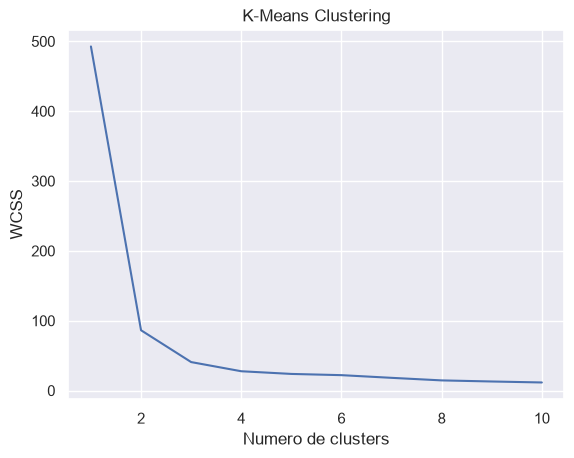

In [6]:
##Graficacion del "Codo de Jmabu"
sb.set()
mp.plot(range(1,11), wcss)
mp.title("K-Means Clustering")
mp.xlabel("Numero de clusters")
mp.ylabel("WCSS") #Weigthed cluster sum of squares

In [7]:
kmeans = KMeans(n_clusters = 3, init = "k-means++", random_state = 42)
cluster_values = kmeans.fit_predict(fields)
print(cluster_values)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 2 0 0 0 0
 0 0 2 0 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 2 0
 0 0]


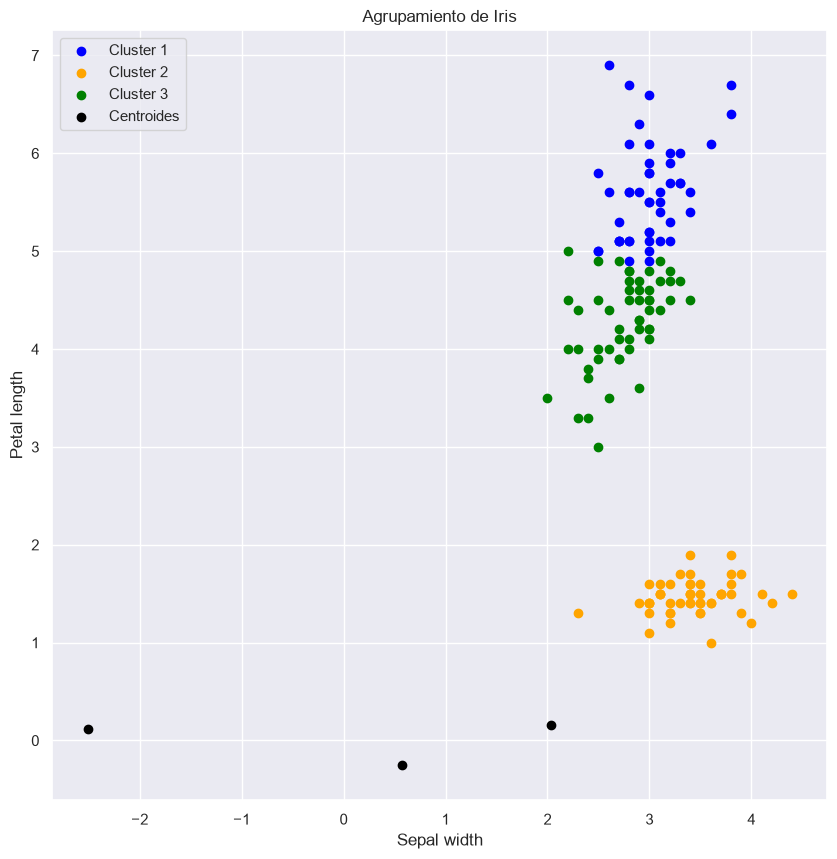

In [21]:
mp.figure(figsize = (10,10))
mp.scatter(fields[cluster_values == 0,0], fields [cluster_values == 0,1], c = 'blue', label = 'Cluster 1')
mp.scatter(fields[cluster_values == 1,0], fields [cluster_values == 1,1], c = 'orange', label = 'Cluster 2')
mp.scatter(fields[cluster_values == 2,0], fields [cluster_values == 2,1], c = 'green', label = 'Cluster 3')

mp.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1], c = 'black', label = 'Centroides')
mp.title("Agrupamiento de Iris")
mp.xlabel("Sepal width") 
mp.ylabel("Petal length")
mp.legend()

In [9]:
#Criterio de silueta ("Silhouette")
from sklearn import datasets
from sklearn.metrics import silhouette_score

In [10]:
X = dataset.iloc[:,[1,2]].to_numpy()
for j in range(2,12):
    kmeans = KMeans (n_clusters = j, random_state = 42)
    kmeans.fit_predict(X)
    #Calculamos el score de silueta 
    score = silhouette_score(X, kmeans.labels_, metric = 'euclidean')
    print("Score Silhuoette;", "k =", j, ":", score)

Score Silhuoette; k = 2 : 0.7392862954615389
Score Silhuoette; k = 3 : 0.5933477102522363
Score Silhuoette; k = 4 : 0.5613370943285366
Score Silhuoette; k = 5 : 0.5068349971009903
Score Silhuoette; k = 6 : 0.37808040954390965
Score Silhuoette; k = 7 : 0.3528070329829507
Score Silhuoette; k = 8 : 0.33737507922227805
Score Silhuoette; k = 9 : 0.33316742872663524
Score Silhuoette; k = 10 : 0.34632325735288505
Score Silhuoette; k = 11 : 0.340427773629915


In [11]:
#Algoritmo KMeans aplicado a 3 columnas de nuestra base original 
#bajo una transformacion de PCA 
fields2 = dataset.iloc[:,[1,2,3]].values
print(fields2)

[[3.5 1.4 0.2]
 [3.  1.4 0.2]
 [3.2 1.3 0.2]
 [3.1 1.5 0.2]
 [3.6 1.4 0.2]
 [3.9 1.7 0.4]
 [3.4 1.4 0.3]
 [3.4 1.5 0.2]
 [2.9 1.4 0.2]
 [3.1 1.5 0.1]
 [3.7 1.5 0.2]
 [3.4 1.6 0.2]
 [3.  1.4 0.1]
 [3.  1.1 0.1]
 [4.  1.2 0.2]
 [4.4 1.5 0.4]
 [3.9 1.3 0.4]
 [3.5 1.4 0.3]
 [3.8 1.7 0.3]
 [3.8 1.5 0.3]
 [3.4 1.7 0.2]
 [3.7 1.5 0.4]
 [3.6 1.  0.2]
 [3.3 1.7 0.5]
 [3.4 1.9 0.2]
 [3.  1.6 0.2]
 [3.4 1.6 0.4]
 [3.5 1.5 0.2]
 [3.4 1.4 0.2]
 [3.2 1.6 0.2]
 [3.1 1.6 0.2]
 [3.4 1.5 0.4]
 [4.1 1.5 0.1]
 [4.2 1.4 0.2]
 [3.1 1.5 0.2]
 [3.2 1.2 0.2]
 [3.5 1.3 0.2]
 [3.6 1.4 0.1]
 [3.  1.3 0.2]
 [3.4 1.5 0.2]
 [3.5 1.3 0.3]
 [2.3 1.3 0.3]
 [3.2 1.3 0.2]
 [3.5 1.6 0.6]
 [3.8 1.9 0.4]
 [3.  1.4 0.3]
 [3.8 1.6 0.2]
 [3.2 1.4 0.2]
 [3.7 1.5 0.2]
 [3.3 1.4 0.2]
 [3.2 4.7 1.4]
 [3.2 4.5 1.5]
 [3.1 4.9 1.5]
 [2.3 4.  1.3]
 [2.8 4.6 1.5]
 [2.8 4.5 1.3]
 [3.3 4.7 1.6]
 [2.4 3.3 1. ]
 [2.9 4.6 1.3]
 [2.7 3.9 1.4]
 [2.  3.5 1. ]
 [3.  4.2 1.5]
 [2.2 4.  1. ]
 [2.9 4.7 1.4]
 [2.9 3.6 1.3]
 [3.1 4.4 1.4]
 [3.  4.5 

In [12]:
from sklearn import decomposition
pca = decomposition.PCA(n_components = 2)
pca.fit(fields2)
fields2 = pca.transform(fields2)
fields2

array([[-2.59236698e+00,  1.82790542e-01],
       [-2.54255916e+00, -3.10617064e-01],
       [-2.65421811e+00, -1.17396707e-01],
       [-2.46078490e+00, -2.07792857e-01],
       [-2.60232854e+00,  2.81472063e-01],
       [-2.27992642e+00,  6.21236571e-01],
       [-2.54386575e+00,  9.97549642e-02],
       [-2.49066959e+00,  8.82517068e-02],
       [-2.53259760e+00, -4.09298585e-01],
       [-2.49932457e+00, -2.23438800e-01],
       [-2.52055428e+00,  3.84296270e-01],
       [-2.39893377e+00,  9.23943926e-02],
       [-2.58109883e+00, -3.26263007e-01],
       [-2.85630630e+00, -3.38691064e-01],
       [-2.82564644e+00,  6.67912776e-01],
       [-2.51320588e+00,  1.10635880e+00],
       [-2.64686971e+00,  6.04665827e-01],
       [-2.55382731e+00,  1.98436485e-01],
       [-2.30850453e+00,  5.06909106e-01],
       [-2.49197617e+00,  4.98623735e-01],
       [-2.30719795e+00,  9.65370785e-02],
       [-2.44347494e+00,  4.15588157e-01],
       [-2.96927183e+00,  2.64901320e-01],
       [-2.

In [17]:
wcss2 = []
for index in range(1,11):
    kmeans = KMeans(n_clusters = index, init = "k-means++", random_state = 2)
    kmeans.fit(fields2)

    wcss2.append(kmeans.inertia_) 

Text(0, 0.5, 'WCSS')

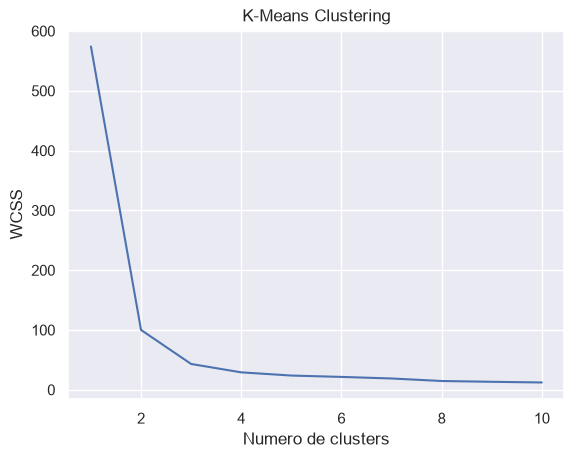

In [18]:
##Graficacion del "Codo de Jmabu"
sb.set()
mp.plot(range(1,11), wcss2)
mp.title("K-Means Clustering")
mp.xlabel("Numero de clusters")
mp.ylabel("WCSS") #Weigthed cluster sum of squares

In [19]:
kmeans = KMeans(n_clusters = 3, init = "k-means++", random_state = 42)
cluster_values = kmeans.fit_predict(fields2)
print(cluster_values)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 2 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 2 0 0 2 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0
 0 0]


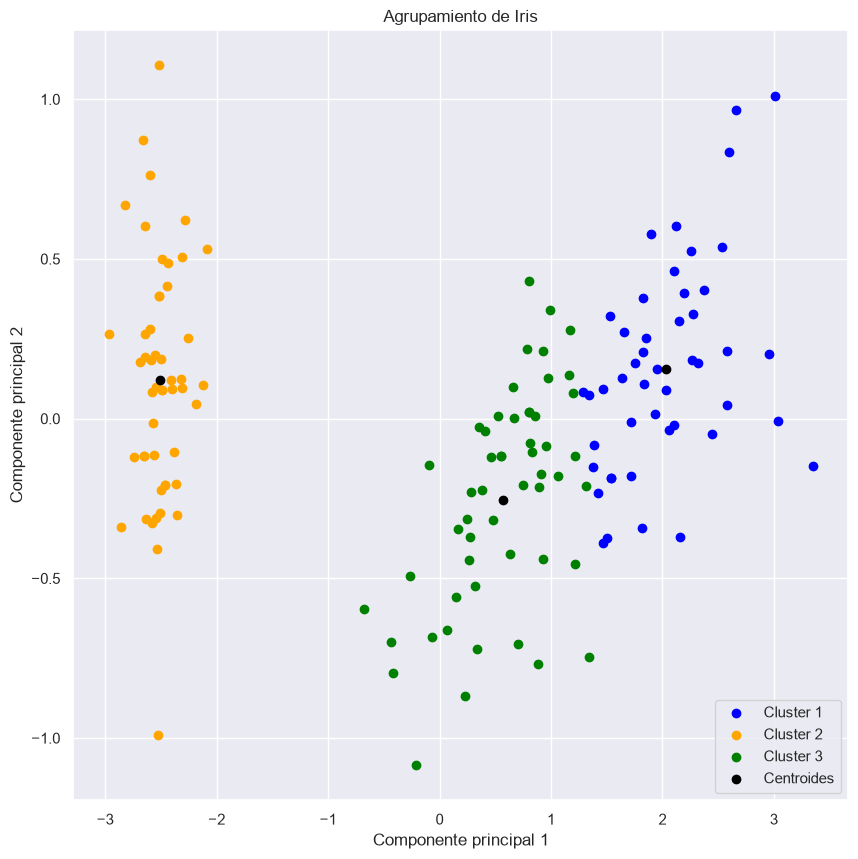

In [23]:
mp.figure(figsize = (10,10))
mp.scatter(fields2[cluster_values == 0,0], fields2 [cluster_values == 0,1], c = 'blue', label = 'Cluster 1')
mp.scatter(fields2[cluster_values == 1,0], fields2 [cluster_values == 1,1], c = 'orange', label = 'Cluster 2')
mp.scatter(fields2[cluster_values == 2,0], fields2 [cluster_values == 2,1], c = 'green', label = 'Cluster 3')

mp.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1], c = 'black', label = 'Centroides')
mp.title("Agrupamiento de Iris")
mp.xlabel("Componente principal 1")
mp.ylabel ("Componente principal 2")
mp.legend()

In [24]:
for j in range(2,12):
    kmeans = KMeans(n_clusters = j, random_state = 42)
    kmeans.fit_predict(fields2)
    score = silhouette_score(fields2, kmeans.labels_, metric = 'euclidean')
    print("Score Silhouette (PCA);", "k =", j, ":", score)

Score Silhouette (PCA); k = 2 : 0.7391565098868098
Score Silhouette (PCA); k = 3 : 0.6147991395660193
Score Silhouette (PCA); k = 4 : 0.564102553018288
Score Silhouette (PCA); k = 5 : 0.5282297333022685
Score Silhouette (PCA); k = 6 : 0.40595779038025454
Score Silhouette (PCA); k = 7 : 0.38851636771919557
Score Silhouette (PCA); k = 8 : 0.34534001687655175
Score Silhouette (PCA); k = 9 : 0.3631835955613131
Score Silhouette (PCA); k = 10 : 0.35779420609326423
Score Silhouette (PCA); k = 11 : 0.3439768244470373


In [ ]:
#¿Obtuvo los mismos resultados de agrupamiento?
#el metodo del codo nos sugiere un numero de clusters de 3 a 4, tanto con PCA como sin PCA, la forma que 
#hay en la curva es casi la misma en ambos casos, lo que nos indica que aplicando PCA no se cambio el numerp 
#de clusters 
#Para el criterio de Silhouette nos indica que k = 2, tanto con PCA como sin PCA, (score = 0.7392 y score = 0.7393)
#los valores son identicos, 